# 04 — Field-controlled inference

**Series:** field-controlled generation in 2D · notebook 4 of 5

Now the two halves meet. Notebook 01 gave us a generative model for the field,
$\mu_\phi$; notebook 03 gave us the conditional model $\mu^\theta(\omega\mid\phi)$.
Sampling from the joint is a two-step ancestral draw:

$$\phi \sim \mu_\phi, \qquad \omega \sim \mu^\theta(\cdot\mid\phi).$$

This notebook is **Algorithm 3** of Part II, in 2D, and mirrors the `--mode latent` +
`--mode decode` path of `0004e-porosity-field-generator.py` — except that here the whole
image is decoded in one shot. Notebook 05 replaces that last step with tiled decoding, and
nothing else changes.

We generate at $1152^2$ and crop to a usable $1024^2$ — **four times larger in each
direction than anything the diffusion model saw in training**.

---
## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time

import numpy as np
import scipy.special
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from diffsci2.extra import two_point_correlation
from diffsci2.extra.matern_gaussian_process import MaternFieldSampler

import fcconfig as fc

fc.ensure_dirs()
torch.manual_seed(0)
np.random.seed(0)

DEVICE = fc.DEVICE
FIELD_CKPT = os.path.join(fc.FIELD_CKPT_DIR, "last.ckpt")
SCALAR_CKPT = os.path.join(fc.SCALAR_CKPT_DIR, "last.ckpt")
for p in (FIELD_CKPT, SCALAR_CKPT, fc.GP_PATH):
    assert os.path.exists(p), f"missing {p} -- run the earlier notebooks"

In [3]:
# --- Algorithm 3 parameters ---
TARGET = 1024                     # usable output edge L
BORDER = fc.BORDER                # border crop b (= R, the averaging radius)
PADDED = TARGET + 2 * BORDER      # generation edge L' = L + 2b  -> 1152
LATENT = PADDED // fc.F           # 144
COARSE_N = fc.COARSE_N            # exact GP grid
NSTEPS = fc.NSTEPS
GUIDANCE = 1.0

assert PADDED % 128 == 0, "keep the padded edge a multiple of 128, as the pipeline requires"
print(f"usable  L  = {TARGET}")
print(f"padded  L' = {PADDED}   (= L + 2b, b = {BORDER})")
print(f"latent     = {LATENT}^2 x {fc.Z_DIM}")
print(f"training patch was {fc.PATCH}^2  ->  generating {PADDED / fc.PATCH:.1f}x larger per axis")

usable  L  = 1024
padded  L' = 1152   (= L + 2b, b = 64)
latent     = 144^2 x 4
training patch was 256^2  ->  generating 4.5x larger per axis


---
## 2. Step 1 — sample the porosity field

Straight from the `.npz` that notebook 01 wrote. Three numbers define the field
distribution; nothing else about the rock is consulted from here on.

The **coarse-to-fine** shortcut appears here: exact sampling on the $144^2$ latent grid
would need the Cholesky factor of a $20736 \times 20736$ matrix. We sample exactly on
$32^2$ and interpolate, accepting the excess smoothness that notebook 01 quantified.

In [4]:
gp = np.load(fc.GP_PATH)
print("fitted Matérn parameters (notebook 01):")
for k in ['mean_logit', 'matern_sigma_sq', 'matern_nu', 'matern_length_scale', 'window']:
    print(f"  {k:22s} {float(gp[k]):.4f}")

sampler = MaternFieldSampler(
    mean_val=float(gp['mean_logit']),
    sigma_sq=float(gp['matern_sigma_sq']),
    nu=float(gp['matern_nu']),
    length_scale=float(gp['matern_length_scale']),
)


def sample_porosity_field(sampler, latent_shape, coarse_n=COARSE_N):
    '''Algorithm 3, lines 2-4: sample the GP coarsely in logit space,
    interpolate to the latent grid, then invert the warp.'''
    H, W = latent_shape
    coarse_h = np.linspace(0.5, H - 0.5, coarse_n)
    coarse_w = np.linspace(0.5, W - 0.5, coarse_n)
    sampler.initialize_field_from_grid(coarse_h, coarse_w)

    fine_h = np.linspace(0.5, H - 0.5, H)
    fine_w = np.linspace(0.5, W - 0.5, W)
    logit_field = sampler.sample_grid_interpolated(1, fine_h, fine_w)[0]
    return scipy.special.expit(logit_field).astype(np.float32)


t0 = time.time()
phi_input = sample_porosity_field(sampler, (LATENT, LATENT))
print(f"\nfield {phi_input.shape} sampled in {time.time() - t0:.1f}s")
print(f"phi in [{phi_input.min():.3f}, {phi_input.max():.3f}], mean {phi_input.mean():.4f}")

fitted Matérn parameters (notebook 01):
  mean_logit             -1.3431
  matern_sigma_sq        0.1380
  matern_nu              1.5000
  matern_length_scale    7.8603
  window                 129.0000

field (144, 144) sampled in 0.1s
phi in [0.083, 0.457], mean 0.1985


---
## 3. Steps 2–4 — the ODE, the decode, the threshold, the crop

`SIModule.sample(..., is_latent_shape=True, return_latents=True)` runs the probability-flow
ODE in latent space and stops **before** decoding, so the two stages stay separable — which
is exactly the split that `0004e` turns into two CLI modes (`--mode latent` /
`--mode decode`) so that sampling can be spread over several GPUs and decoding done
separately.

In [5]:
flow_model = fc.load_flow_model(FIELD_CKPT, conditional=True)
vae = fc.load_vae()
module = fc.make_si_module(flow_model, autoencoder=vae).to(DEVICE).eval()
print("field-conditioned model loaded")

field-conditioned model loaded


In [6]:
@torch.no_grad()
def generate(module, phi_latent=None, scalar=None, seed=None,
             nsteps=NSTEPS, guidance=GUIDANCE, border=BORDER):
    '''Algorithm 3. Returns (binary_cropped, binary_uncropped, latent).

    phi_latent -> field conditioning        (FC)
    scalar     -> single porosity value     (Controlled baseline)
    neither    -> y = None                  (Uncond baseline)
    '''
    if seed is not None:
        torch.manual_seed(seed)

    if phi_latent is not None:
        y = {'porosity': torch.tensor(phi_latent, dtype=torch.float32)}
        shape = [fc.Z_DIM, *phi_latent.shape]
    else:
        shape = [fc.Z_DIM, LATENT, LATENT]
        y = ({'porosity': torch.tensor([scalar], dtype=torch.float32)}
             if scalar is not None else None)

    z0 = module.sample(1, shape=shape, y=y, nsteps=nsteps,
                       is_latent_shape=True, return_latents=True, guidance=guidance)
    x = module.decode(z0)[0][0, 0].cpu().numpy()          # continuous pixel space
    binary = (x > x.mean()).astype(np.float32)            # mean-threshold binarisation
    cropped = binary[border:-border, border:-border] if border > 0 else binary
    return cropped, binary, z0


t0 = time.time()
fc_crop, fc_full, z_fc = generate(module, phi_latent=phi_input, seed=2024)
print(f"generated {fc_full.shape} -> cropped {fc_crop.shape} in {time.time() - t0:.0f}s")
print(f"porosity: uncropped {1 - fc_full.mean():.4f}   cropped {1 - fc_crop.mean():.4f}")

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:2
  warnings.warn("Moving y to device: {}".format(self.device))


generated (1152, 1152) -> cropped (1024, 1024) in 1s
porosity: uncropped 0.1977   cropped 0.1891


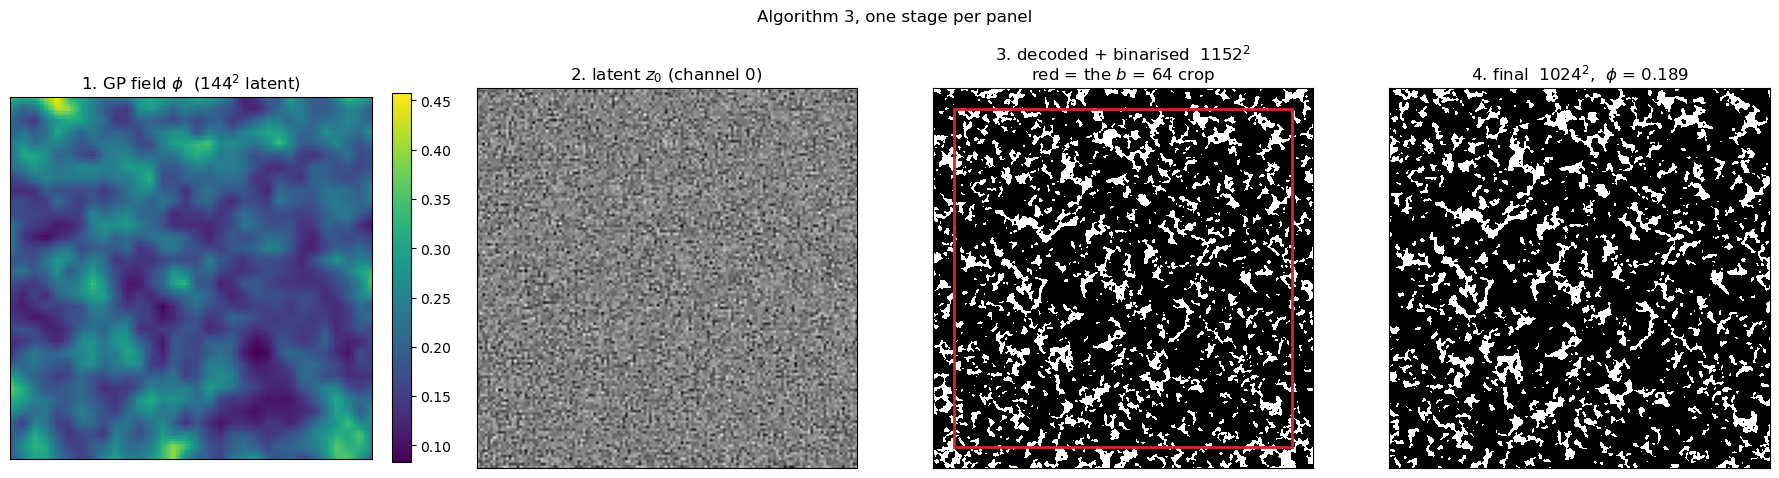

In [7]:
def latent_field_of(binary, window=fc.WINDOW, factor=fc.F):
    '''Realised porosity field of a binary image, on the latent grid.

    Same definition as the conditioning field: a local average over a window of
    `window` voxels, and only THEN pooled by F. Pooling the binary straight down
    by F gives the pore fraction of each F x F block -- a window-8 field, a
    different quantity that on real rock correlates with the true window-129
    field at only rho ~ 0.18.

    Mirrors scripts/old/0007-porosity-field-evaluation.py.
    '''
    return fc.realised_field(binary, window=window, factor=factor)


phi_out_full = latent_field_of(fc_full)
b_lat = BORDER // fc.F
phi_in_crop = phi_input[b_lat:-b_lat, b_lat:-b_lat]
phi_out_crop = phi_out_full[b_lat:-b_lat, b_lat:-b_lat]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
im = axes[0].imshow(phi_input, cmap='viridis', interpolation='nearest')
axes[0].set_title(f"1. GP field $\\phi$  ({LATENT}$^2$ latent)")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(z_fc[0, 0].cpu().numpy(), cmap='gray')
axes[1].set_title("2. latent $z_0$ (channel 0)")

axes[2].imshow(fc_full, cmap='gray_r', interpolation='nearest')
axes[2].add_patch(plt.Rectangle((BORDER, BORDER), TARGET, TARGET,
                                fill=False, edgecolor='C3', lw=2))
axes[2].set_title(f"3. decoded + binarised  {PADDED}$^2$\nred = the $b$ = {BORDER} crop")

axes[3].imshow(fc_crop, cmap='gray_r', interpolation='nearest')
axes[3].set_title(f"4. final  {TARGET}$^2$,  $\\phi$ = {1 - fc_crop.mean():.3f}")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Algorithm 3, one stage per panel", y=1.03)
fig.tight_layout()
fc.savefig(fig, "04_pipeline_stages")
plt.show()

### Why the border crop exists

Convolutional padding makes the model behave differently near the image edge, and the
conditioning field is least trustworthy there too. The thesis picks $b$ equal to the
largest averaging radius $R$. We can see the effect directly by plotting the realised
porosity as a function of distance from the boundary.

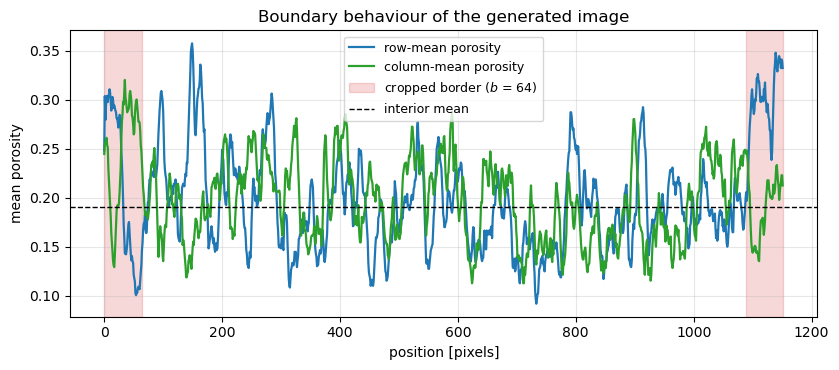

In [8]:
# Row/column mean pore fraction of the raw binary -- a purely local measure, so the
# profile shows the model's boundary behaviour and not the porosity field's own
# 'same'-mode normalisation near the edge.
prof_rows = (1.0 - fc_full).mean(axis=1)
prof_cols = (1.0 - fc_full).mean(axis=0)
dist = np.arange(len(prof_rows))            # in pixels

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(dist, prof_rows, 'C0-', lw=1.6, label='row-mean porosity')
ax.plot(dist, prof_cols, 'C2-', lw=1.6, label='column-mean porosity')
ax.axvspan(0, BORDER, color='C3', alpha=0.18, label=f'cropped border ($b$ = {BORDER})')
ax.axvspan(PADDED - BORDER, PADDED, color='C3', alpha=0.18)
ax.axhline(phi_out_crop.mean(), color='k', ls='--', lw=1,
           label='interior mean')
ax.set_xlabel("position [pixels]"); ax.set_ylabel("mean porosity")
ax.set_title("Boundary behaviour of the generated image")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fc.savefig(fig, "04_border_effect")
plt.show()

---
## 4. The three strategies, side by side

The thesis compares field conditioning against two alternatives that use the **same
pretrained weights** and differ only in what is passed as `y` at generation time:

| name | conditioning | what it assumes |
|---|---|---|
| **FC** | GP-sampled porosity field | large-scale heterogeneity is captured by $\phi$ |
| **Uncond** | `y = None` | the convolutional architecture self-averages into realistic heterogeneity |
| **Controlled** | one scalar, drawn from the empirical porosity distribution | the whole image has a single porosity |

Reference: real Berea, same size, from held-out slices.

In [9]:
slices = fc.load_slices()
fields = fc.load_fields()
R = fc.RADIUS

# Reference crops from validation slices.
reference = []
for i in range(fc.TRAIN_SLICES, min(fc.TRAIN_SLICES + 6, fc.N_SLICES)):
    ref = np.asarray(slices[i], dtype=np.float32)[R:R + TARGET, R:R + TARGET]
    reference.append(ref)
print(f"{len(reference)} reference crops of {reference[0].shape}, "
      f"mean porosity {np.mean([1 - r.mean() for r in reference]):.4f}")

# A plausible scalar for the Controlled baseline: draw from the real field's values,
# exactly as sample_scalar_porosity() does in 0004e.
real_field_values = np.asarray(fields[0], dtype=np.float32)[R:-R, R:-R].ravel()
scalar_value = float(np.random.choice(real_field_values))
print(f"Controlled baseline scalar: {scalar_value:.4f}")

6 reference crops of (936, 936), mean porosity 0.2158
Controlled baseline scalar: 0.2036


In [10]:
uncond_model = fc.load_flow_model(FIELD_CKPT, conditional=False)
uncond_module = fc.make_si_module(uncond_model, autoencoder=fc.load_vae()).to(DEVICE).eval()

t0 = time.time()
un_crop, _, _ = generate(uncond_module, seed=2024)
ct_crop, _, _ = generate(module, scalar=scalar_value, seed=2024)
print(f"baselines generated in {time.time() - t0:.0f}s")

samples = {
    'reference': reference[0],
    'FC (field)': fc_crop,
    'Uncond': un_crop,
    'Controlled (scalar)': ct_crop,
}
for k, v in samples.items():
    print(f"  {k:22s} phi = {1 - v.mean():.4f}")

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:2
  warnings.warn("Moving y to device: {}".format(self.device))


baselines generated in 1s
  reference              phi = 0.2122
  FC (field)             phi = 0.1891
  Uncond                 phi = 0.1931
  Controlled (scalar)    phi = 0.1875


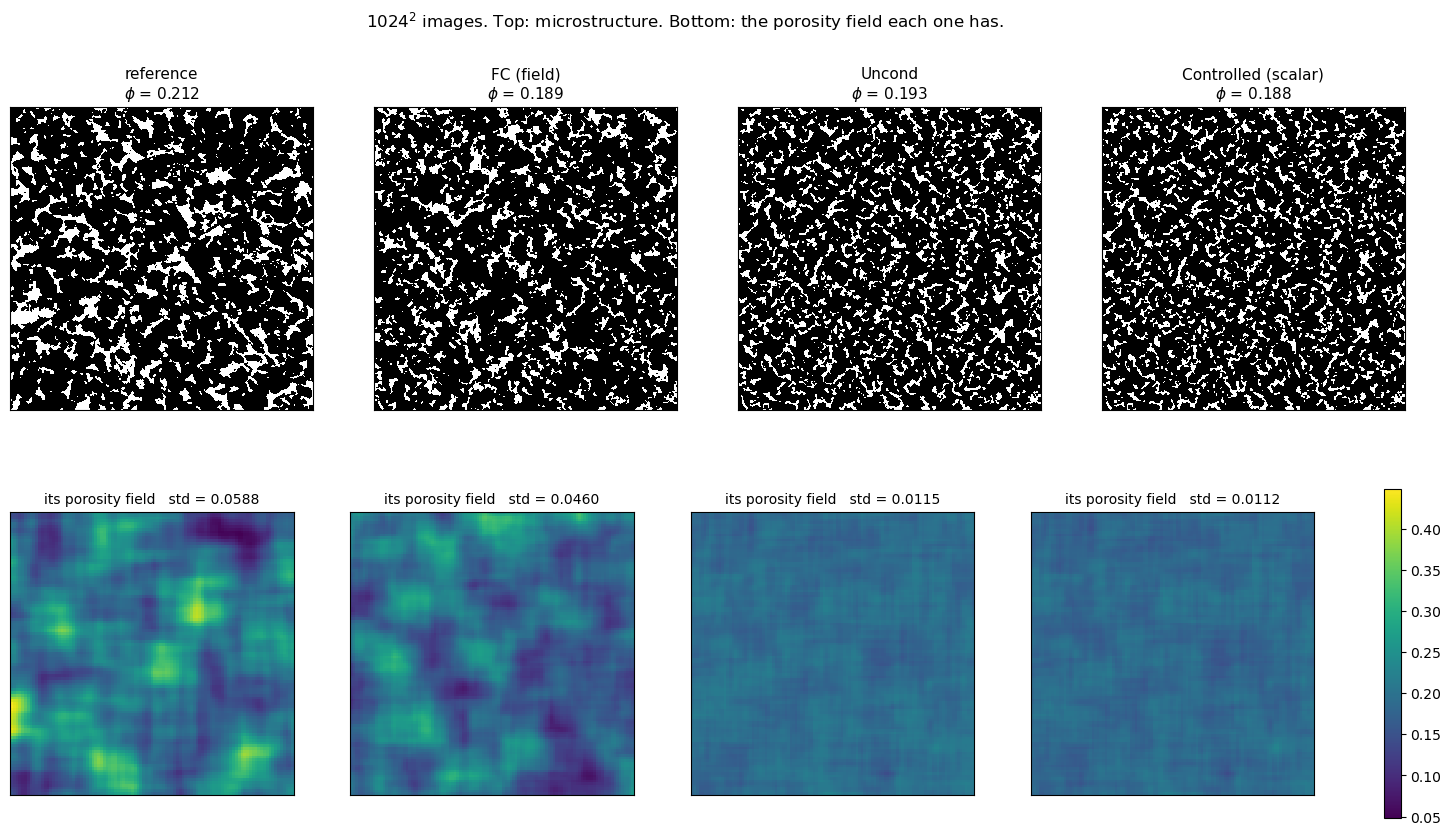

In [11]:
# Interiors only: the 'same'-mode field is unreliable within R of each image's border.
sample_fields = {name: fc.field_interior(latent_field_of(img))
                 for name, img in samples.items()}
fvmin = min(f.min() for f in sample_fields.values())
fvmax = max(f.max() for f in sample_fields.values())

fig, axes = plt.subplots(2, 4, figsize=(18, 9.4))
for k, (name, img) in enumerate(samples.items()):
    axes[0, k].imshow(img, cmap='gray_r', interpolation='nearest')
    axes[0, k].set_title(f"{name}\n$\\phi$ = {1 - img.mean():.3f}", fontsize=11)
    lf = sample_fields[name]
    im = axes[1, k].imshow(lf, cmap='viridis', vmin=fvmin, vmax=fvmax, interpolation='nearest')
    axes[1, k].set_title(f"its porosity field   std = {lf.std():.4f}", fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[1, :], fraction=0.015)
fig.suptitle(f"{TARGET}$^2$ images. Top: microstructure. Bottom: the porosity field each one has.",
             y=0.97)
fc.savefig(fig, "04_method_comparison")
plt.show()

The bottom row is the point of the whole chapter. **Controlled** produces a field that is
nearly flat — a scalar cannot express heterogeneity. **Uncond** produces heterogeneity, but
whatever heterogeneity the architecture happens to self-average into. **FC** produces the
heterogeneity it was told to.

---
## 5. Sub-block diversity

The thesis argues that the only coherent requirement we can place on an upscaling method
is that the **distribution of sub-block properties matches the reference**. So: cut each
$1024^2$ image into a $4\times4$ grid of $256^2$ sub-blocks, and compare the resulting
porosity distributions. Scored with the Gaussian Hellinger distance $H_G$.

In [12]:
def sub_block_porosities(img, grid=4):
    n = img.shape[0] // grid
    return np.array([1 - img[i * n:(i + 1) * n, j * n:(j + 1) * n].mean()
                     for i in range(grid) for j in range(grid)])


ref_blocks = np.concatenate([sub_block_porosities(r) for r in reference])
block_stats = {name: sub_block_porosities(img) for name, img in samples.items()
               if name != 'reference'}

print(f"{'method':<22} {'mean':>8} {'std':>8} {'H_G vs ref':>12}")
print(f"{'reference':<22} {ref_blocks.mean():>8.4f} {ref_blocks.std():>8.4f} {'-':>12}")
for name, vals in block_stats.items():
    print(f"{name:<22} {vals.mean():>8.4f} {vals.std():>8.4f} "
          f"{fc.gaussian_hellinger(vals, ref_blocks):>12.4f}")

method                     mean      std   H_G vs ref
reference                0.2158   0.0330            -
FC (field)               0.1891   0.0230       0.3643
Uncond                   0.1931   0.0053       0.7075
Controlled (scalar)      0.1875   0.0053       0.7284


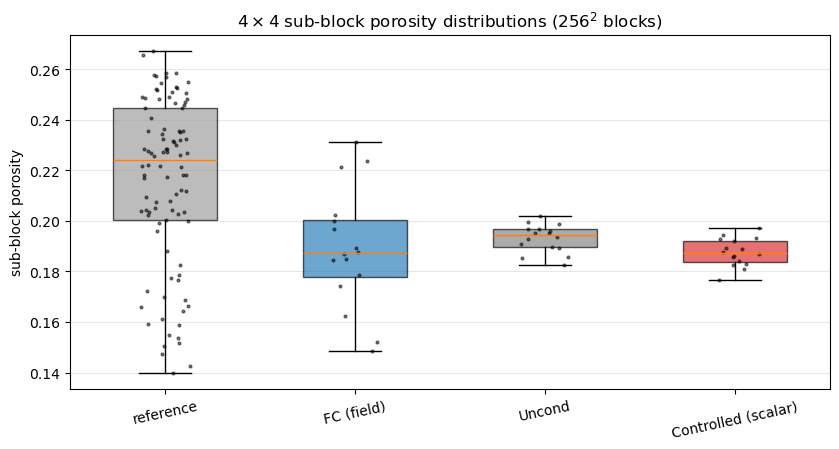

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
data = [ref_blocks] + [block_stats[k] for k in block_stats]
names = ['reference'] + list(block_stats)
colors = ['0.6', 'C0', 'C7', 'C3']
bp = ax.boxplot(data, patch_artist=True, widths=0.55)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.65)
for k, vals in enumerate(data):
    ax.plot(np.full(len(vals), k + 1) + np.random.uniform(-0.13, 0.13, len(vals)),
            vals, 'k.', ms=4, alpha=0.5)
ax.set_xticklabels(names, rotation=12)
ax.set_ylabel("sub-block porosity")
ax.set_title("$4\\times4$ sub-block porosity distributions ($256^2$ blocks)")
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fc.savefig(fig, "04_subblock_diversity")
plt.show()

`Controlled` collapses: every sub-block has the same porosity, because that is literally
what it was asked for. This reproduces the thesis result that scalar conditioning
"produces wildly erratic sub-block distributions ... suppressing intra-volume
heterogeneity", and is why it is dropped from the later comparisons there.

---
## 6. Field-controlling mechanism analysis

Three diagnostics, the 2D versions of the figures in *§Field-controlling mechanism
analysis* of Part II:

1. **voxel-wise scatter** of requested $\phi$ against realised $\hat\phi$;
2. **two-point covariance** of the logit field: true rock vs. GP input vs. generated;
3. **mean and variance reproduction** of the logit field.

In [14]:
N_SAMPLES = 4
gen_pairs = []
t0 = time.time()
for s in range(N_SAMPLES):
    phi_i = sample_porosity_field(sampler, (LATENT, LATENT))
    crop, full, _ = generate(module, phi_latent=phi_i, seed=100 + s)
    gen_pairs.append((phi_i[b_lat:-b_lat, b_lat:-b_lat], latent_field_of(full)[b_lat:-b_lat, b_lat:-b_lat], crop))
print(f"{N_SAMPLES} samples in {(time.time() - t0) / 60:.1f} min")

rhos = [np.corrcoef(a.ravel(), b.ravel())[0, 1] for a, b, _ in gen_pairs]
print(f"voxel-wise field correlation: rho = {np.mean(rhos):.3f} +/- {np.std(rhos):.3f}")

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:2
  warnings.warn("Moving y to device: {}".format(self.device))


4 samples in 0.0 min
voxel-wise field correlation: rho = 0.934 +/- 0.005


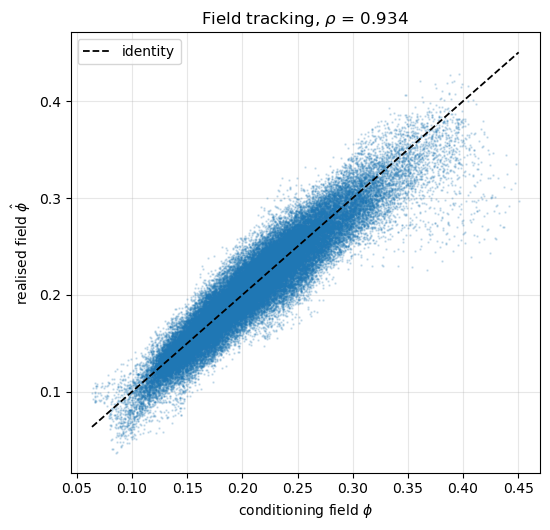

In [15]:
fig, ax = plt.subplots(figsize=(5.6, 5.4))
for a, b, _ in gen_pairs:
    ax.plot(a.ravel(), b.ravel(), '.', ms=1.6, alpha=0.18, color='C0')
lims = [min(a.min() for a, _, _ in gen_pairs), max(a.max() for a, _, _ in gen_pairs)]
ax.plot(lims, lims, 'k--', lw=1.3, label='identity')
ax.set_xlabel("conditioning field $\\phi$")
ax.set_ylabel("realised field $\\hat{\\phi}$")
ax.set_title(f"Field tracking, $\\rho$ = {np.mean(rhos):.3f}")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fc.savefig(fig, "04_field_correlation")
plt.show()

In [16]:
def logit_np(x, eps=1e-6):
    x = np.clip(x, eps, 1 - eps)
    return np.log(x / (1 - x))


def radial_norm(field_stack, bins=40):
    '''Normalised radial covariance C(r)/C(0) of a stack of logit fields.'''
    curves = []
    for f in field_stack:
        c = np.asarray(two_point_correlation.tpcf_fft(
            torch.tensor(f - f.mean(), dtype=torch.float32), bins=bins, voxel_size=1.0).correlation)
        curves.append(c / c[0])
    rr = np.asarray(two_point_correlation.tpcf_fft(
        torch.tensor(field_stack[0] - field_stack[0].mean(), dtype=torch.float32),
        bins=bins, voxel_size=1.0).r)
    return rr, np.mean(curves, axis=0), np.std(curves, axis=0)


# true field (from the rock), GP input field, generated field -- all in logit space.
# The rock's latent field is (1000 - 2R)/F = 109 across, the generated one is 128;
# radial covariances are only comparable on a common window, so crop all three.
true_latent = []
for i in range(fc.TRAIN_SLICES, min(fc.TRAIN_SLICES + N_SAMPLES, fc.N_SLICES)):
    f_i = np.asarray(fields[i], dtype=np.float32)[R:-R, R:-R]
    true_latent.append(F.avg_pool2d(torch.from_numpy(f_i)[None, None], fc.F, fc.F)[0, 0].numpy())

COMMON = min(true_latent[0].shape[0], gen_pairs[0][0].shape[0])
print(f"comparing all fields on a common {COMMON}^2 window "
      f"(rock: {true_latent[0].shape[0]}^2, generated: {gen_pairs[0][0].shape[0]}^2)")

true_stack = [logit_np(f[:COMMON, :COMMON]) for f in true_latent]
input_stack = [logit_np(a[:COMMON, :COMMON]) for a, _, _ in gen_pairs]
gen_stack = [logit_np(b[:COMMON, :COMMON]) for _, b, _ in gen_pairs]

rr, c_true, s_true = radial_norm(true_stack)
_, c_in, s_in = radial_norm(input_stack)
_, c_gen, s_gen = radial_norm(gen_stack)

comparing all fields on a common 109^2 window (rock: 109^2, generated: 128^2)


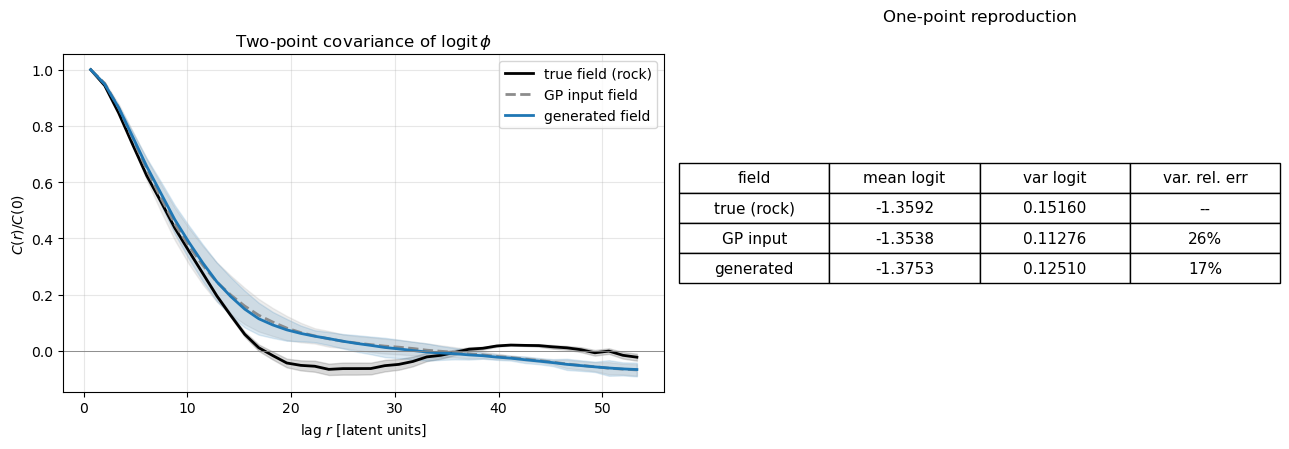

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
for c, s, col, lab, ls in [(c_true, s_true, 'k', 'true field (rock)', '-'),
                           (c_in, s_in, '0.55', 'GP input field', '--'),
                           (c_gen, s_gen, 'C0', 'generated field', '-')]:
    ax.fill_between(rr, c - s, c + s, color=col, alpha=0.15)
    ax.plot(rr, c, ls, color=col, lw=2, label=lab)
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel("lag $r$ [latent units]"); ax.set_ylabel("$C(r)/C(0)$")
ax.set_title("Two-point covariance of $\\operatorname{logit}\\phi$")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
rows = [
    ('true (rock)', np.mean([f.mean() for f in true_stack]), np.mean([f.var() for f in true_stack])),
    ('GP input', np.mean([f.mean() for f in input_stack]), np.mean([f.var() for f in input_stack])),
    ('generated', np.mean([f.mean() for f in gen_stack]), np.mean([f.var() for f in gen_stack])),
]
ax.axis('off')
table = ax.table(
    cellText=[[n, f"{m:.4f}", f"{v:.5f}",
               f"{100 * abs(v - rows[0][2]) / rows[0][2]:.0f}%" if k else "--"]
              for k, (n, m, v) in enumerate(rows)],
    colLabels=['field', 'mean logit', 'var logit', 'var. rel. err'],
    loc='center', cellLoc='center')
table.scale(1, 1.9); table.set_fontsize(11)
ax.set_title("One-point reproduction", pad=24)

fig.tight_layout()
fc.savefig(fig, "04_field_tpc_and_stats")
plt.show()

Read this the way the thesis does. The **mean** of the field is reproduced well — the
conditioning correctly sets the overall porosity level. The **variance** is not, and the
generated curve tracks the *GP input* rather than the *true* field. Two causes stack:

1. the coarse-grid-plus-interpolation GP sampler under-produces fine-scale variance
   (measured in notebook 01 §9);
2. the diffusion model follows the field only partially — it is a soft constraint.

The practical consequence stated in Part II is that **the quality of the field model is the
bottleneck**, not the diffusion model, and that a better field sampler (circulant embedding,
two-point optimisation) would improve the whole method without touching anything else.

---
## 7. Zooming in

A generated $1024^2$ image is not usefully judged from a thumbnail. The microstructure has
to look like rock at full resolution *and* the large-scale variation has to be there.

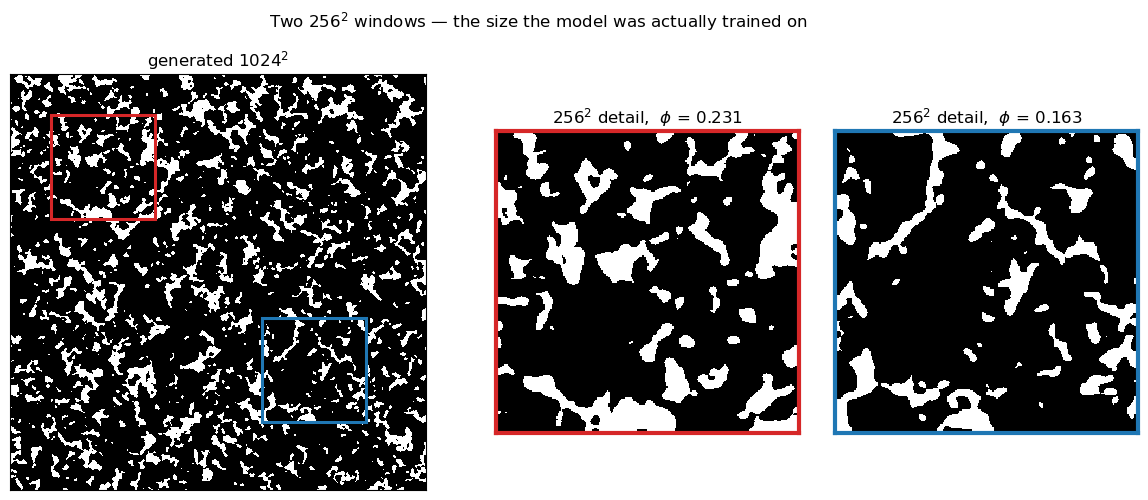

In [18]:
fig = plt.figure(figsize=(15, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.6, 1, 1], wspace=0.1)

ax = fig.add_subplot(gs[0])
ax.imshow(fc_crop, cmap='gray_r', interpolation='nearest')
for (i, j), col in [((100, 100), 'C3'), ((600, 620), 'C0')]:
    ax.add_patch(plt.Rectangle((j, i), 256, 256, fill=False, edgecolor=col, lw=2.2))
ax.set_title(f"generated {TARGET}$^2$")

for k, ((i, j), col) in enumerate([((100, 100), 'C3'), ((600, 620), 'C0')]):
    ax = fig.add_subplot(gs[k + 1])
    sub = fc_crop[i:i + 256, j:j + 256]
    ax.imshow(sub, cmap='gray_r', interpolation='nearest')
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(3)
    ax.set_title(f"$256^2$ detail,  $\\phi$ = {1 - sub.mean():.3f}")

for ax in fig.axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Two $256^2$ windows — the size the model was actually trained on", y=1.0)
fc.savefig(fig, "04_zoom_detail")
plt.show()

---
## 8. Why this notebook stops at $1024^2$

Decoding was done in one shot: the decoder held every intermediate activation for the whole
$1152^2$ image on the GPU at once. In 2D that is affordable. Let us measure it, and then
extrapolate to what the thesis actually needs.

In [19]:
def decode_peak_memory(module, latent_size, device=DEVICE):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    z = torch.randn(1, fc.Z_DIM, latent_size, latent_size, device=device)
    with torch.no_grad():
        _ = module.decode(z)
    peak = torch.cuda.max_memory_allocated(device) / 2 ** 30
    del z
    torch.cuda.empty_cache()
    return peak


print(f"{'pixel size':>12} {'latent':>8} {'peak GPU (GiB)':>16}")
peaks = {}
for L in [256, 512, 1024, 1152]:
    peaks[L] = decode_peak_memory(module, L // fc.F)
    print(f"{L:>12} {L // fc.F:>8} {peaks[L]:>16.2f}")

  pixel size   latent   peak GPU (GiB)
         256       32             0.20
         512       64             0.41
        1024      128             1.26
        1152      144             1.56


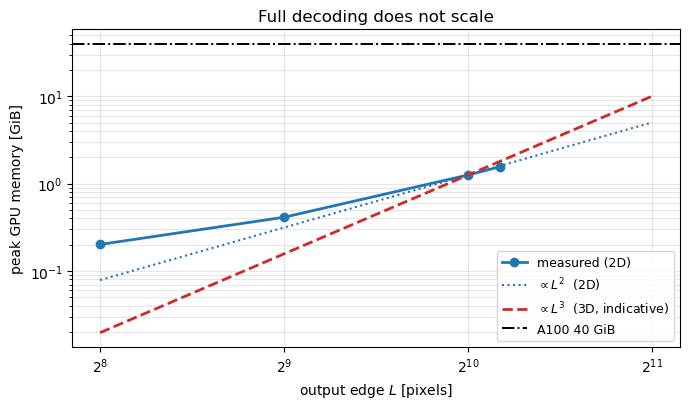

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.2))
Ls = np.array(sorted(peaks))
ax.plot(Ls, [peaks[L] for L in Ls], 'o-', color='C0', lw=2, label='measured (2D)')

# The same activation budget in 3D grows with L^3 instead of L^2.
scale2d = peaks[1024] / 1024 ** 2
LL = np.array([256, 512, 1024, 2048])
ax.plot(LL, scale2d * LL ** 2, 'C0:', lw=1.5, label='$\\propto L^2$  (2D)')
ax.plot(LL, scale2d * LL ** 3 / 1024, 'C3--', lw=2, label='$\\propto L^3$  (3D, indicative)')
ax.axhline(40, color='k', ls='-.', lw=1.4, label='A100 40 GiB')
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel("output edge $L$ [pixels]"); ax.set_ylabel("peak GPU memory [GiB]")
ax.set_title("Full decoding does not scale")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fc.savefig(fig, "04_decode_memory_scaling")
plt.show()

In 3D at $L = 1024$ this wall is hit hard — which is exactly why the thesis introduces
chunk decoding, and why the timing table there shows *most of the generation time spent in
decoding*, not in sampling.

---
## What to carry forward

- Generation is an **ancestral two-step draw**: field first, microstructure second.
  Algorithm 3 is nothing more than that plus bookkeeping (padding, thresholding, cropping).
- The three baselines differ **only in what is passed as `y`**. Same weights, same code path.
- Field conditioning reproduces sub-block diversity; scalar conditioning destroys it.
- The field is followed as a **soft** constraint, and the generated field inherits the
  smoothness of the GP input. The field model is the bottleneck.
- One-shot decoding scales as the output volume. That is the last obstacle.

**Next:** `05-chunk-decoding.ipynb` — remove the decoding wall, keep everything else.